In [1]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Patch
mpl.rcParams['figure.dpi'] = 150

In [2]:
# source = "scream"
# source = "nicam_gl11"
# source = "um_glm_n2560_RAL3p3"
# source = "icon_d3hp003"
# source = "ifs_tco3999_rcbmf"
# source = "casesm2_10km_nocumulus"
source = "IMERGv7"

# MCS masks
# root_dir = f"/pscratch/sd/w/wcmca1/hackathon/mcs/{source}/mcstracking/"
# # in_zarr = f"{root_dir}{source}_mcs_masks_hp8.zarr"
# in_zarr = f"{root_dir}scream2D_hrly_mcsmask_hp8_v1.zarr"

year = '2021'
root_dir = f"/pscratch/sd/w/wcmca1/hackathon/mcs/IMERGv7/mcstracking/"
in_zarr = f"{root_dir}IMERGv7_hrly_mcsmask_hp8_v1_{year}0101.0000_{int(year)+1}0101.0100.zarr"
# in_zarr = f"{root_dir}IMERGv7_hrly_mcsmask_hp8_v1_20200101.0000_20210101.0100.zarr"

in_zarr

# # Combined all feature masks
# root_dir = "/pscratch/sd/w/wcmca1/hackathon/all_masks/"
# in_zarr = f"{root_dir}{source}_allmasks_hp8_v1.zarr"
# in_zarr

'/pscratch/sd/w/wcmca1/hackathon/mcs/IMERGv7/mcstracking/IMERGv7_hrly_mcsmask_hp8_v1_20210101.0000_20220101.0100.zarr'

In [3]:
ds = xr.open_zarr(in_zarr, consolidated=True)
ds

<xarray.Dataset> Size: 110GB
Dimensions:   (time: 8758, cell: 786432, crs: 0)
Coordinates:
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
  * crs       (crs) float64 0B 
  * time      (time) datetime64[ns] 70kB 2021-01-01 ... 2021-12-31T23:00:00
Data variables:
    ccs_mask  (time, cell) float64 55GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    mcs_mask  (time, cell) float64 55GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
Attributes: (12/15)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Mon Mar 16 20:07:18 2026
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    pf_smooth_window:          5
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [4]:
ds.time[0:10]

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['2021-01-01T00:00:00.000000000', '2021-01-01T01:00:00.000000000',
       '2021-01-01T02:00:00.000000000', '2021-01-01T03:00:00.000000000',
       '2021-01-01T04:00:00.000000000', '2021-01-01T05:00:00.000000000',
       '2021-01-01T06:00:00.000000000', '2021-01-01T07:00:00.000000000',
       '2021-01-01T08:00:00.000000000', '2021-01-01T09:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 80B 2021-01-01 ... 2021-01-01T09:00:00
Attributes:
    long_name:  Base time in Epoch

In [5]:
ds.chunks

Frozen({'time': (24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24,

In [6]:
ds.mcs_mask.attrs

{'comments': 'This mask renumbers small merge/split tracks to the main track (e.g., MCS)',
 'long_name': 'Track number including merge/split',
 'units': 'unitless'}

In [7]:
# itime = 1401
# # itime = 1201
# cloud_types = ds.cloud_types.isel(time=itime)
# egh.healpix_show(cloud_types.where(cloud_types > 0), vmin=0, vmax=4, cmap='tab20')

<Figure size 960x720 with 0 Axes>

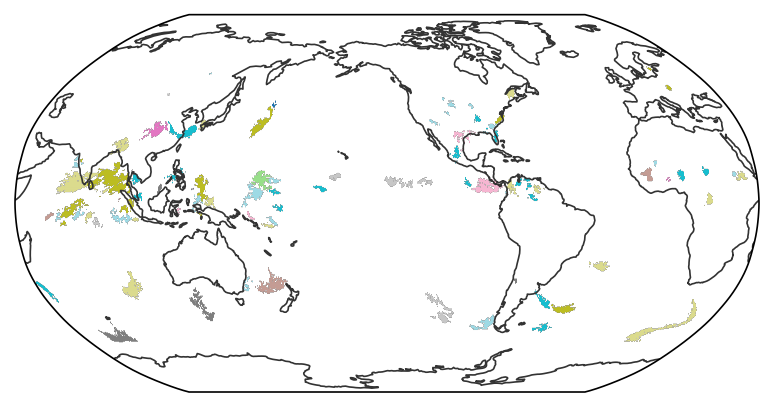

In [8]:
# itime = 1021
# itime = 1401
itime = f'{year}-07-10T00'
mcs_mask = ds.mcs_mask.sel(time=itime)
egh.healpix_show(mcs_mask.where(mcs_mask > 0), cmap='tab20')

In [9]:
sdate = f'{year}-08-01T00'
edate = f'{year}-08-31T23'

mcs_binary = ds.mcs_mask.sel(time=slice(sdate, edate)) > 0
mcs_count = mcs_binary.sum(dim='time')
nhours = ds.time.sel(time=slice(sdate, edate)).count()

mcs_freq = 100 * mcs_count / nhours

<Figure size 960x720 with 0 Axes>

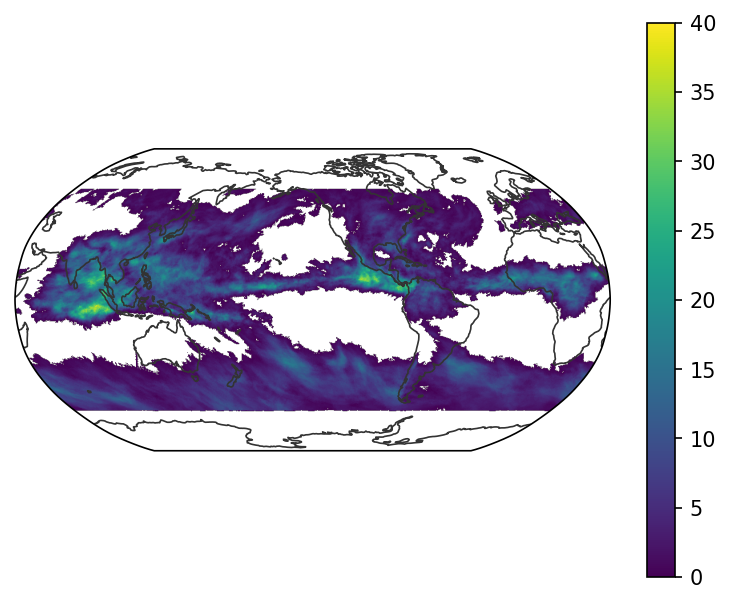

In [10]:
img = egh.healpix_show(mcs_freq.where(mcs_freq > 0), vmin=0, vmax=40)
plt.colorbar(img)

In [11]:
mcs_freq.max().values

array(38.17204301)